# ДЗ 2 — Plan-and-Execute агент на LangGraph
**Моісеєнко Світлана** · курс «Проєктування автономних агентів» (теми 3–4)

## Мета
Побудувати агента з архітектурою **Plan-and-Execute** — розширення ReAct з ДЗ 1 — та три production-можливості:
**persistence** (SqliteSaver), **agentic RAG** (ChromaDB) і **human-in-the-loop** (interrupt/approval).

## Ключова відмінність від ReAct (ДЗ 1)
| | ReAct (ДЗ 1) | Plan-and-Execute (ДЗ 2) |
|---|---|---|
| Рішення про наступний крок | «на льоту», після кожного observation | повний план заздалегідь |
| Структура графа | цикл `agent → tools → agent` | `planner → executor → replanner` |
| Корекція курсу | неявна, у наступному thought | явна: `continue / revise / finish` |
| Сильна сторона | короткі задачі, швидка реакція | складні задачі з 3+ послідовних дій |

## Структура ноутбука
| Секція | Зміст |
|---|---|
| 0 | Встановлення залежностей |
| 1 | Імпорти та конфігурація |
| 2 | База знань: ChromaDB з 10 документів |
| 3 | Інструменти з Pydantic-валідацією (включно з ризиковим `book_hotel`) |
| 4 | Structured outputs (`Plan`, `ReplanDecision`) та LLM-провайдер з офлайн-фолбеком |
| 5 | Plan-and-Execute граф + SqliteSaver + HITL interrupt |
| 6 | Демо 1: agentic RAG — агент сам вирішує, коли йти в базу знань |
| 7 | Демо 2: replanning після помилки інструмента |
| 8 | Демо 3: persistence — «збій процесу» та відновлення за `thread_id` |
| 9 | Демо 4: HITL — approve та reject ризикової дії |
| 10 | Візуалізація результатів |
| 11 | Висновки та аналіз |

## Секція 0. Встановлення залежностей
Клітинка ідемпотентна: у Colab доставляє відсутні пакети, локально — нічого не робить.
Нове порівняно з ДЗ 1: `langgraph-checkpoint-sqlite` (persistence) та `chromadb` (vector store).

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "langgraph": "langgraph",
    "langgraph.checkpoint.sqlite": "langgraph-checkpoint-sqlite",
    "langchain_core": "langchain-core",
    "langchain_openai": "langchain-openai",
    "chromadb": "chromadb",
    "pydantic": "pydantic>=2",
    "matplotlib": "matplotlib",
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f"Встановлюю: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Усі залежності доступні")

Усі залежності доступні


## Секція 1. Імпорти та конфігурація
`AgentConfig` обмежує довжину плану (`max_plan_steps`) і загальну кількість виконаних кроків
(`max_total_steps`) — guardrail проти нескінченного replanning.

In [2]:
import ast
import hashlib
import json
import math
import operator
import os
import re
import sqlite3
import time
from collections import Counter
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.tools import BaseTool, tool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field, field_validator

OUTPUT_DIR = Path.cwd()
CHECKPOINT_DB = OUTPUT_DIR / "checkpoints.sqlite"
RUN_LOG_PATH = OUTPUT_DIR / "run_log.json"


class AgentConfig(BaseModel):
    """Налаштування Plan-and-Execute агента та його захисних механізмів."""

    max_plan_steps: int = Field(default=8, ge=1, le=20, description="Максимальна довжина плану")
    max_total_steps: int = Field(default=12, ge=1, le=50, description="Ліміт виконаних кроків (guardrail проти нескінченного replanning)")
    model_name: str = Field(default="gpt-4.1", description="Назва моделі провайдера")
    temperature: float = Field(default=0.0, ge=0.0, le=2.0)


CONFIG = AgentConfig()


def save_json(payload: Any, path: Path) -> None:
    """Зберігає структуру у JSON-файл з підтримкою кирилиці."""
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Збережено: {path.name} ({path.stat().st_size / 1024:.1f} КБ)")


print(f"Python {sys.version.split()[0]}")
print(f"Конфігурація: max_plan_steps={CONFIG.max_plan_steps}, max_total_steps={CONFIG.max_total_steps}")

Python 3.11.8
Конфігурація: max_plan_steps=8, max_total_steps=12


## Секція 2. База знань — ChromaDB (10 документів)

Доменна область — **подорожі Україною**: міста, бюджетування, політика бронювання, транспорт, безпека.

`HashingEmbedding` — детермінований локальний ембеддинг (хешування слів і символьних 3-грам):
ноутбук працює без мережі та API-ключів, а результати пошуку однакові на будь-якій машині.
Для production достатньо замінити його на `OpenAIEmbeddings` чи `sentence-transformers` — інтерфейс той самий.
Колекція використовує косинусну відстань, тому нижче показується `similarity = 1 − distance`.

In [3]:
# База знань доменної області «Подорожі Україною»: 10 документів для ChromaDB.
KNOWLEDGE_DOCS = {
    "lviv": "Львів — місто кави та архітектури. Обов'язкові локації: площа Ринок, Оперний театр, Високий Замок. "
            "Готелі в центрі коштують 2500–4000 грн за ніч, найпопулярніший — готель «Опера» біля Оперного театру.",
    "karpaty": "Карпати — головний гірський напрямок України. Відпочинок у Карпатах пасує і влітку, і взимку: "
               "трекінг на Говерлу (2061 м) та лижний курорт Буковель. Оптимальна тривалість поїздки — 3–5 днів, "
               "базове місто — Яремче.",
    "kyiv": "Київ — столиця України. Головні пам'ятки: Софійський собор, Києво-Печерська лавра, Андріївський узвіз. "
            "Середні витрати туриста — близько 2000 грн на день без урахування житла.",
    "odesa": "Одеса — морська столиця України. Пляжний сезон триває з травня по вересень. "
            "Варто відвідати Дерибасівську, Оперний театр та узбережжя Аркадії.",
    "kharkiv": "Харків — студентське та наукове місто. Цікаві локації: площа Свободи, сад Шевченка, Держпром. "
               "Зручне залізничне сполучення з Києвом — швидкісний Інтерсіті їде близько 4 годин.",
    "budgeting": "Правило розподілу бюджету подорожі: 40% на житло, 30% на їжу, 20% на транспорт і розваги, "
                 "10% — резерв на непередбачені витрати. Плануйте бюджет у гривнях за актуальним курсом.",
    "booking_policy": "Політика бронювання готелів: бронювання є фінансовим зобов'язанням. "
                      "Безкоштовне скасування можливе не пізніше ніж за 48 годин до заселення. "
                      "Перед підтвердженням бронювання перевірте дати, місто та загальну вартість.",
    "currency": "Національна валюта України — гривня (UAH). Розрахунки картками доступні майже всюди. "
                "Обмінювати валюту варто у банках, а не у вуличних обмінниках із «привабливим» курсом.",
    "transport": "Міжміський транспорт: Укрзалізниця (сайт або застосунок), швидкісні поїзди Інтерсіті+, "
                 "автобусні перевізники. Квитки на популярні напрямки варто купувати за 2–3 тижні.",
    "safety": "Безпека подорожей: оформіть страховку, тримайте копії документів у хмарі, "
              "збережіть номери екстрених служб. У прикордонні регіони поїздки не рекомендовані.",
}

import chromadb
from chromadb.api.types import EmbeddingFunction


class HashingEmbedding(EmbeddingFunction):
    """Детермінований локальний ембеддинг без мережі: хешування слів і символьних 3-грам у вектор.

    Слова та 3-грами покривають морфологію української («Львів» ↔ «Львові» мають спільні грами),
    md5-хеш дає стабільні індекси, отже результати пошуку відтворювані на будь-якій машині.
    Повні слова важать утричі більше за грами, стоп-слова до 2 символів відкидаються.
    """

    def __init__(self, dim: int = 512, word_weight: float = 3.0):
        self.dim = dim
        self.word_weight = word_weight

    def _bucket(self, token: str) -> int:
        return int(hashlib.md5(token.encode()).hexdigest(), 16) % self.dim

    def __call__(self, input: list[str]) -> list[list[float]]:
        vectors = []
        for text in input:
            vec = [0.0] * self.dim
            tokens = [t for t in re.findall(r"\w+", text.lower()) if len(t) > 2]
            for token in tokens:
                vec[self._bucket(token)] += self.word_weight
                for i in range(max(len(token) - 2, 1)):
                    vec[self._bucket(token[i:i + 3])] += 1.0
            norm = math.sqrt(sum(x * x for x in vec)) or 1.0
            vectors.append([x / norm for x in vec])
        return vectors

    @staticmethod
    def name() -> str:
        return "hashing-embedding"


chroma_client = chromadb.EphemeralClient()
knowledge = chroma_client.get_or_create_collection(
    "travel_ukraine",
    embedding_function=HashingEmbedding(),
    metadata={"hnsw:space": "cosine"},
)
knowledge.upsert(ids=list(KNOWLEDGE_DOCS), documents=list(KNOWLEDGE_DOCS.values()))
print(f"ChromaDB-колекція '{knowledge.name}': {knowledge.count()} документів")

probe = knowledge.query(query_texts=["готель у Львові"], n_results=2)
for doc_id, doc, dist in zip(probe["ids"][0], probe["documents"][0], probe["distances"][0]):
    print(f"  {doc_id:15} similarity={1 - dist:.3f}  {doc[:60]}…")

ChromaDB-колекція 'travel_ukraine': 10 документів
  lviv            similarity=0.205  Львів — місто кави та архітектури. Обов'язкові локації: площ…
  budgeting       similarity=0.047  Правило розподілу бюджету подорожі: 40% на житло, 30% на їжу…


## Секція 3. Інструменти з Pydantic-валідацією

| Інструмент | Призначення | Особливість |
|---|---|---|
| `search_knowledge` | **RAG**: семантичний пошук у ChromaDB | агент сам вирішує, коли викликати |
| `calculator` | арифметика | безпечний AST, без `eval` довільного коду |
| `convert_currency` | конвертація валют | перевірка кодів валют |
| `get_weather` | погода в місті | перевірка довідника міст |
| `book_hotel` | бронювання готелю | **ризиковий → HITL**: потребує підтвердження людини |

In [4]:
USD_RATES = {"USD": 1.0, "EUR": 0.92, "UAH": 41.50, "PLN": 3.98, "GBP": 0.79}

WEATHER_DB = {
    "Київ": {"temp_c": 18.5, "description": "мінлива хмарність", "humidity_percent": 62},
    "Львів": {"temp_c": 15.0, "description": "дощ", "humidity_percent": 81},
    "Одеса": {"temp_c": 24.0, "description": "ясно", "humidity_percent": 55},
    "Харків": {"temp_c": 20.0, "description": "хмарно", "humidity_percent": 68},
}

HOTEL_PRICES_UAH = {"Опера": 3200, "Дністер": 2600, "Прем'єр Палац": 5400}

_ALLOWED_EXPR = re.compile(r"^[0-9+\-*/().,%\s]+$")
_SAFE_AST_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.FloorDiv, ast.Mod, ast.Pow, ast.USub, ast.UAdd,
)


def _as_json(payload: dict) -> str:
    """Уніфікований формат результату інструмента для LLM."""
    return json.dumps(payload, ensure_ascii=False)


class SearchKnowledgeArgs(BaseModel):
    """Параметри інструмента search_knowledge."""

    query: str = Field(description="Пошуковий запит до бази знань про подорожі Україною")
    top_k: int = Field(default=2, ge=1, le=5, description="Скільки документів повернути")

    @field_validator("query")
    @classmethod
    def validate_query(cls, value: str) -> str:
        query = value.strip()
        if len(query) < 3:
            raise ValueError("Запит закороткий (мінімум 3 символи)")
        return query


class CalculatorArgs(BaseModel):
    """Параметри інструмента calculator."""

    expression: str = Field(description="Арифметичний вираз, напр. '2400*0.15+300'")

    @field_validator("expression")
    @classmethod
    def validate_expression(cls, value: str) -> str:
        value = value.strip()
        if not value or len(value) > 200 or not _ALLOWED_EXPR.match(value):
            raise ValueError("Дозволені лише цифри, дужки та оператори + - * / % ** //, до 200 символів")
        return value


class ConvertCurrencyArgs(BaseModel):
    """Параметри інструмента convert_currency."""

    amount: float = Field(gt=0, le=1_000_000_000, description="Сума для конвертації")
    from_currency: str = Field(description=f"Код валюти-джерела: {', '.join(USD_RATES)}")
    to_currency: str = Field(description=f"Код цільової валюти: {', '.join(USD_RATES)}")

    @field_validator("from_currency", "to_currency")
    @classmethod
    def validate_currency(cls, value: str) -> str:
        code = value.strip().upper()
        if code not in USD_RATES:
            raise ValueError(f"Невідома валюта '{value}'. Доступні: {', '.join(USD_RATES)}")
        return code


class WeatherArgs(BaseModel):
    """Параметри інструмента get_weather."""

    city: str = Field(description=f"Назва міста українською: {', '.join(WEATHER_DB)}")

    @field_validator("city")
    @classmethod
    def validate_city(cls, value: str) -> str:
        city = value.strip().capitalize()
        if city not in WEATHER_DB:
            raise ValueError(f"Немає даних для міста '{value}'. Доступні: {', '.join(WEATHER_DB)}")
        return city


class BookHotelArgs(BaseModel):
    """Параметри ризикового інструмента book_hotel."""

    hotel: str = Field(description=f"Назва готелю: {', '.join(HOTEL_PRICES_UAH)}")
    city: str = Field(description="Місто, у якому розташований готель")
    nights: int = Field(ge=1, le=30, description="Кількість ночей")

    @field_validator("hotel")
    @classmethod
    def validate_hotel(cls, value: str) -> str:
        hotel = value.strip()
        if hotel not in HOTEL_PRICES_UAH:
            raise ValueError(f"Невідомий готель '{value}'. Доступні: {', '.join(HOTEL_PRICES_UAH)}")
        return hotel


@tool("search_knowledge", args_schema=SearchKnowledgeArgs)
def search_knowledge(query: str, top_k: int = 2) -> str:
    """Шукає у базі знань про подорожі Україною (RAG). Використовуй для фактів про міста, бюджети, правила бронювання."""
    found = knowledge.query(query_texts=[query], n_results=top_k)
    documents = [
        {"doc_id": doc_id, "similarity": round(1 - dist, 3), "text": doc}
        for doc_id, doc, dist in zip(found["ids"][0], found["documents"][0], found["distances"][0])
    ]
    return _as_json({"query": query, "documents": documents})


@tool("calculator", args_schema=CalculatorArgs)
def calculator(expression: str) -> str:
    """Обчислює арифметичний вираз (додавання, віднімання, множення, ділення, відсотки, степінь)."""
    tree = ast.parse(expression.replace(",", "."), mode="eval")
    for node in ast.walk(tree):
        if not isinstance(node, _SAFE_AST_NODES):
            raise ValueError(f"Недозволена конструкція у виразі: {type(node).__name__}")
    result = eval(compile(tree, "<expression>", "eval"))
    return _as_json({"expression": expression, "result": round(float(result), 4)})


@tool("convert_currency", args_schema=ConvertCurrencyArgs)
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    """Конвертує суму з однієї валюти в іншу за фіксованим курсом довідника."""
    rate = USD_RATES[to_currency] / USD_RATES[from_currency]
    return _as_json({
        "amount": amount, "from": from_currency, "to": to_currency,
        "rate": round(rate, 4), "result": round(amount * rate, 2),
    })


@tool("get_weather", args_schema=WeatherArgs)
def get_weather(city: str) -> str:
    """Повертає поточну погоду у місті: температуру, опис та вологість."""
    return _as_json({"city": city, **WEATHER_DB[city]})


@tool("book_hotel", args_schema=BookHotelArgs)
def book_hotel(hotel: str, city: str, nights: int) -> str:
    """РИЗИКОВА ДІЯ: бронює готель (фінансове зобов'язання). Потребує підтвердження людини."""
    total = HOTEL_PRICES_UAH[hotel] * nights
    booking_id = hashlib.md5(f"{hotel}|{city}|{nights}".encode()).hexdigest()[:8].upper()
    return _as_json({
        "booking_id": booking_id, "hotel": hotel, "city": city, "nights": nights,
        "price_per_night_uah": HOTEL_PRICES_UAH[hotel], "total_uah": total, "status": "confirmed",
    })


TOOLS: list[BaseTool] = [search_knowledge, calculator, convert_currency, get_weather, book_hotel]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
RISKY_TOOLS = {"book_hotel"}


def try_tool(name: str, args: dict) -> str:
    """Викликає інструмент і перетворює будь-яку помилку валідації у текст для LLM."""
    try:
        return TOOLS_BY_NAME[name].invoke(args)
    except Exception as error:
        reasons = list(dict.fromkeys(re.findall(r"Value error, (.+?)(?: \[type=|$)", str(error))))
        details = "; ".join(reasons) or str(error).strip().splitlines()[0]
        return f"ERROR [{type(error).__name__}]: {details}"


for tool_obj in TOOLS:
    marker = " [РИЗИКОВИЙ → HITL]" if tool_obj.name in RISKY_TOOLS else ""
    print(f"{tool_obj.name:18}{marker}\n{'':20}{tool_obj.description}")

search_knowledge  
                    Шукає у базі знань про подорожі Україною (RAG). Використовуй для фактів про міста, бюджети, правила бронювання.
calculator        
                    Обчислює арифметичний вираз (додавання, віднімання, множення, ділення, відсотки, степінь).
convert_currency  
                    Конвертує суму з однієї валюти в іншу за фіксованим курсом довідника.
get_weather       
                    Повертає поточну погоду у місті: температуру, опис та вологість.
book_hotel         [РИЗИКОВИЙ → HITL]
                    РИЗИКОВА ДІЯ: бронює готель (фінансове зобов'язання). Потребує підтвердження людини.


### Перевірка Pydantic-валідації
Валідні виклики повертають JSON, невалідні — зрозумілу помилку, яку replanner зможе прочитати й скоригувати план.

In [5]:
VALIDATION_CHECKS = [
    ("search_knowledge", {"query": "правила бронювання готелю", "top_k": 1}),
    ("search_knowledge", {"query": "ab"}),
    ("get_weather", {"city": "Париж"}),
    ("book_hotel", {"hotel": "Опера", "city": "Львів", "nights": 3}),
    ("book_hotel", {"hotel": "Хілтон", "city": "Львів", "nights": 3}),
]

for name, args in VALIDATION_CHECKS:
    print(f"{name}({args})\n  → {try_tool(name, args)}\n")

search_knowledge({'query': 'правила бронювання готелю', 'top_k': 1})
  → {"query": "правила бронювання готелю", "documents": [{"doc_id": "booking_policy", "similarity": 0.459, "text": "Політика бронювання готелів: бронювання є фінансовим зобов'язанням. Безкоштовне скасування можливе не пізніше ніж за 48 годин до заселення. Перед підтвердженням бронювання перевірте дати, місто та загальну вартість."}]}

search_knowledge({'query': 'ab'})
  → ERROR [ValidationError]: Запит закороткий (мінімум 3 символи)

get_weather({'city': 'Париж'})
  → ERROR [ValidationError]: Немає даних для міста 'Париж'. Доступні: Київ, Львів, Одеса, Харків

book_hotel({'hotel': 'Опера', 'city': 'Львів', 'nights': 3})
  → {"booking_id": "3F069D92", "hotel": "Опера", "city": "Львів", "nights": 3, "price_per_night_uah": 3200, "total_uah": 9600, "status": "confirmed"}

book_hotel({'hotel': 'Хілтон', 'city': 'Львів', 'nights': 3})
  → ERROR [ValidationError]: Невідомий готель 'Хілтон'. Доступні: Опера, Дністер, Прем'єр 

## Секція 4. Structured outputs: `Plan` і `ReplanDecision`

* **`Plan`** — вихід планувальника: впорядкований список кроків (1–10).
* **`ReplanDecision`** — вихід replanner-а: `continue` (план актуальний), `revise` (новий залишок плану
  у `steps`), `finish` (фінальна відповідь у `response`) + обов'язкове пояснення `reason`.

Обидві моделі передаються у `llm.with_structured_output(...)`, тож відповідь LLM завжди валідується Pydantic-ом.

In [6]:
class Plan(BaseModel):
    """Structured output планувальника: впорядкований список кроків."""

    steps: list[str] = Field(min_length=1, max_length=10,
                             description="Кроки плану у порядку виконання, кожен — одна конкретна дія")


class ReplanDecision(BaseModel):
    """Structured output replanner-а: рішення після виконання чергового кроку."""

    action: Literal["continue", "revise", "finish"] = Field(
        description="continue — виконувати план далі; revise — замінити залишок плану; finish — дати фінальну відповідь")
    steps: list[str] = Field(default_factory=list, description="Новий залишок плану (лише для revise)")
    response: str = Field(default="", description="Фінальна відповідь користувачу (лише для finish)")
    reason: str = Field(description="Коротке пояснення рішення")


PLANNER_PROMPT = f"""Ти — планувальник агента подорожей Україною. Склади мінімальний покроковий план виконання запиту.
Доступні інструменти: {', '.join(TOOLS_BY_NAME)}.
Правила:
- Кожен крок — одна конкретна дія, яку можна виконати одним інструментом (або коротким висновком).
- Факти про міста, бюджети та правила бронювання бери З БАЗИ ЗНАНЬ (search_knowledge), а не з пам'яті.
- Не додавай зайвих кроків: для простої арифметики база знань не потрібна.
- Відповідай structured output-ом Plan."""

EXECUTOR_PROMPT = """Ти — виконавець одного кроку плану. Виконай ЛИШЕ поточний крок:
виклич один потрібний інструмент або, якщо крок підсумковий, дай текстову відповідь на основі виконаних кроків."""

REPLANNER_PROMPT = """Ти — replanner агента. Проаналізуй виконані кроки та залишок плану і виріши:
- continue — якщо план актуальний і кроки ще залишились;
- revise — якщо останній результат містить помилку або план застарів (передай новий залишок плану у steps);
- finish — якщо даних достатньо або дію відхилила людина (передай фінальну відповідь у response).
Відповідай structured output-ом ReplanDecision."""

for model in (Plan, ReplanDecision):
    print(f"{model.__name__}: {', '.join(model.model_fields)}")

Plan: steps
ReplanDecision: action, steps, response, reason


### LLM-провайдер

**Основний** — OpenAI `gpt-4.1` через `ChatOpenAI` (потрібен `OPENAI_API_KEY`).

**Фолбек** — `ScriptedPlanExecLLM`: детермінована офлайн-реалізація `BaseChatModel`, що емулює всі три ролі
(планувальник, виконавець, replanner) за схемою прив'язаних інструментів. Завдяки цьому ноутбук
повністю відтворюється без ключа, а демонстрації replanning/HITL/persistence — стабільні.

In [7]:
CITY_STEMS = {"львів": "Львів", "львов": "Львів", "київ": "Київ", "києв": "Київ",
              "одес": "Одеса", "харк": "Харків", "париж": "Париж"}

# Сценарії офлайн-планувальника: ключові слова запиту → план.
PLAN_SCENARIOS: list[tuple[tuple[str, ...], list[str]]] = [
    (("львов", "поїздк"), [
        "Знайди в базі знань інформацію про Львів та готелі",
        "Перевір погоду у Львові",
        "Конвертуй 300 USD у UAH",
        "Порахуй добовий бюджет: поділи отриману суму в гривнях на 3 дні",
        "Забронюй готель «Опера» у Львові на 3 ночі",
    ]),
    (("карпат",), [
        "Знайди в базі знань інформацію про відпочинок у Карпатах",
        "Перевір погоду у Львові",
        "Конвертуй 100 USD у UAH",
    ]),
    (("порівняй", "париж"), [
        "Перевір погоду у Львові",
        "Перевір погоду в Парижі",
        "Сформуй порівняння погоди для користувача",
    ]),
    (("15%",), ["Порахуй 15% від 2400 і додай 300"]),
]


def _match_city(text: str) -> str:
    """Знаходить місто за морфологічним стемом у тексті кроку."""
    low = text.lower()
    return next((city for stem, city in CITY_STEMS.items() if stem in low), "Київ")


def _last_number(text: str, pattern: str = r'"result":\s*([\d.]+)') -> float | None:
    """Витягає останнє числове значення result із блоку виконаних кроків."""
    found = re.findall(pattern, text)
    return float(found[-1]) if found else None


class ScriptedPlanExecLLM(BaseChatModel):
    """Детермінований офлайн-фолбек для Plan-and-Execute.

    Емулює три ролі за схемою прив'язаних інструментів:
    - bind_tools([Plan]) → планувальник (structured output Plan);
    - bind_tools([ReplanDecision]) → replanner (structured output ReplanDecision);
    - bind_tools(TOOLS) → виконавець кроку (tool calling).
    Рішення детерміновані й керуються текстом промпту, тому ноутбук відтворюється без API-ключа.
    """

    bound_tools: list[dict] = Field(default_factory=list)

    @property
    def _llm_type(self) -> str:
        return "scripted-offline"

    def bind_tools(self, tools: list, **kwargs: Any) -> "ScriptedPlanExecLLM":
        return self.model_copy(update={"bound_tools": [convert_to_openai_tool(t) for t in tools]})

    def _generate(self, messages: list[AnyMessage], stop=None, run_manager=None, **kwargs) -> ChatResult:
        bound = [t["function"]["name"] for t in self.bound_tools]
        prompt = messages[-1].content
        if bound == ["Plan"]:
            message = self._plan(prompt)
        elif bound == ["ReplanDecision"]:
            message = self._replan(prompt)
        else:
            message = self._execute_step(prompt)
        return ChatResult(generations=[ChatGeneration(message=message)])

    @staticmethod
    def _structured(name: str, args: dict) -> AIMessage:
        return AIMessage(content="", tool_calls=[{"name": name, "args": args, "id": f"call_{name.lower()}"}])

    @staticmethod
    def _tool_call(name: str, args: dict, thought: str) -> AIMessage:
        return AIMessage(content=thought, tool_calls=[{"name": name, "args": args, "id": f"call_{name}"}])

    @staticmethod
    def _section(prompt: str, header: str) -> list[str]:
        """Повертає рядки '- …' з відповідного блоку промпту."""
        block = prompt.split(header, 1)[-1].split("\n\n", 1)[0]
        return [line[2:].strip() for line in block.splitlines() if line.strip().startswith("- ")]

    def _plan(self, prompt: str) -> AIMessage:
        low = prompt.lower()
        for keywords, steps in PLAN_SCENARIOS:
            if all(k in low for k in keywords):
                return self._structured("Plan", {"steps": steps})
        return self._structured("Plan", {"steps": [f"Дай пряму відповідь на запит: {prompt[:80]}"]})

    def _execute_step(self, prompt: str) -> AIMessage:
        step = prompt.split("Поточний крок плану: ", 1)[-1].splitlines()[0]
        low = step.lower()
        if any(k in low for k in ("сформуй", "підсум", "порівнян", "дай пряму відповідь")):
            done = self._section(prompt, "Виконані кроки:")
            return AIMessage(content="Підсумок на основі зібраних даних: " + ("; ".join(done) or "даних немає"))
        if "базі знань" in low or "знайди" in low:
            query = step.split("про ", 1)[-1]
            return self._tool_call("search_knowledge", {"query": query, "top_k": 2},
                                   "Звертаюся до бази знань.")
        if "погод" in low:
            return self._tool_call("get_weather", {"city": _match_city(step)}, "Перевіряю погоду.")
        if "конверт" in low:
            amount, source, target = re.search(r"(\d+(?:[.,]\d+)?)\s*([A-Z]{3})\D+([A-Z]{3})", step).groups()
            return self._tool_call("convert_currency",
                                   {"amount": float(amount), "from_currency": source, "to_currency": target},
                                   "Конвертую валюту.")
        if "поділи" in low:
            amount = _last_number(prompt) or 0.0
            divisor = re.search(r"на (\d+)", low).group(1)
            return self._tool_call("calculator", {"expression": f"{amount}/{divisor}"}, "Рахую бюджет.")
        if "15%" in low:
            base, add = re.search(r"від (\d+).*?додай (\d+)", low).groups()
            return self._tool_call("calculator", {"expression": f"{base}*0.15+{add}"}, "Рахую вираз.")
        if "заброн" in low:
            hotel = re.search(r"[«'\"](.+?)[»'\"]", step)
            nights = re.search(r"на (\d+) ноч", low)
            return self._tool_call("book_hotel",
                                   {"hotel": hotel.group(1) if hotel else "Опера",
                                    "city": _match_city(step),
                                    "nights": int(nights.group(1)) if nights else 3},
                                   "Бронюю готель (ризикова дія).")
        # Невідомий крок: відповідаємо текстом на основі попередніх результатів.
        done = self._section(prompt, "Виконані кроки:")
        return AIMessage(content="Підсумок на основі зібраних даних: " + ("; ".join(done) or "даних немає"))

    def _replan(self, prompt: str) -> AIMessage:
        remaining = self._section(prompt, "Залишок плану:")
        done = self._section(prompt, "Виконані кроки:")
        # Аналізуємо лише результат ОСТАННЬОГО кроку (текст після «→»).
        last_result = done[-1].split(" → ", 1)[-1] if done else ""
        if last_result.startswith("ERROR") and "париж" in last_result.lower():
            return self._structured("ReplanDecision", {
                "action": "revise", "steps": ["Перевір погоду в Одесі"] + remaining,
                "reason": "Париж недоступний у джерелі погоди — замінюю на запасне місто Одеса"})
        if last_result.startswith("ERROR"):
            return self._structured("ReplanDecision", {
                "action": "finish", "response": f"Не вдалося виконати план: {last_result}",
                "reason": "критична помилка інструмента"})
        if last_result.startswith("ВІДХИЛЕНО"):
            return self._structured("ReplanDecision", {
                "action": "finish",
                "response": "Бронювання скасовано за рішенням людини. Зібрані дані (погода, бюджет) "
                            "збережені у кроках плану — готель можна обрати вручну.",
                "reason": "людина відхилила ризикову дію"})
        if remaining:
            return self._structured("ReplanDecision", {"action": "continue", "reason": "план актуальний"})
        if last_result.startswith("Підсумок"):
            response = last_result
        else:
            response = "Готово. Результати кроків: " + (" | ".join(d[:120] for d in done) or "кроки не виконувалися")
        return self._structured("ReplanDecision", {
            "action": "finish", "response": response, "reason": "усі кроки плану виконано"})


def build_llm(config: AgentConfig = CONFIG) -> BaseChatModel:
    """Створює LLM: OpenAI за наявності ключа, інакше детермінований офлайн-фолбек."""
    if os.getenv("OPENAI_API_KEY"):
        from langchain_openai import ChatOpenAI

        return ChatOpenAI(model=config.model_name, temperature=config.temperature)
    return ScriptedPlanExecLLM()


ACTIVE_LLM = build_llm()
print(f"Активний провайдер: {ACTIVE_LLM._llm_type}")
print(f"Модель: {getattr(ACTIVE_LLM, 'model_name', CONFIG.model_name)}")

Активний провайдер: scripted-offline
Модель: gpt-4.1


## Секція 5. Plan-and-Execute граф + SqliteSaver + HITL

**Стан** (`PlanExecState`): запит, залишок плану, виконані кроки, журнал рішень, фінальна відповідь.

**Вузли:**
* `planner` — генерує план (structured output `Plan`);
* `executor` — виконує ОДИН крок плану за ітерацію (tool call або текстовий підсумок);
  перед **ризиковим** інструментом викликає `interrupt()` і чекає на рішення людини;
* `replanner` — вирішує `continue / revise / finish` (structured output `ReplanDecision`).

**Checkpointer** — `SqliteSaver` поверх файлу `checkpoints.sqlite` (не `:memory:`):
кожен крок графа зберігається, тому виконання можна перервати й продовжити за `thread_id`.

In [8]:
class PlanExecState(TypedDict):
    """Стан Plan-and-Execute графа."""

    input: str
    plan: list[str]
    past_steps: Annotated[list[dict], operator.add]
    decisions: Annotated[list[dict], operator.add]
    response: str


def _format_steps(items: list[str]) -> str:
    return "\n".join(f"- {s}" for s in items) or "(порожньо)"


def _format_past(past: list[dict]) -> str:
    return "\n".join(f"- {p['step']} → {p['result']}" for p in past) or "(порожньо)"


def build_plan_execute_graph(llm: BaseChatModel, checkpointer: SqliteSaver,
                             config: AgentConfig = CONFIG, interrupt_before: list[str] | None = None):
    """Збирає граф planner → executor → replanner з HITL-interrupt для ризикових інструментів."""
    planner_llm = llm.with_structured_output(Plan)
    replanner_llm = llm.with_structured_output(ReplanDecision)
    executor_llm = llm.bind_tools(TOOLS)

    def planner_node(state: PlanExecState) -> dict:
        plan = planner_llm.invoke([SystemMessage(PLANNER_PROMPT), HumanMessage(state["input"])])
        steps = plan.steps[:config.max_plan_steps]
        return {"plan": steps,
                "decisions": [{"node": "planner", "action": "plan", "steps": steps}]}

    def executor_node(state: PlanExecState) -> dict:
        step = state["plan"][0]
        prompt = (f"Запит користувача: {state['input']}\n"
                  f"Виконані кроки:\n{_format_past(state['past_steps'])}\n\n"
                  f"Поточний крок плану: {step}")
        response = executor_llm.invoke([SystemMessage(EXECUTOR_PROMPT), HumanMessage(prompt)])

        if response.tool_calls:
            call = response.tool_calls[0]
            tool_name = call["name"]
            if tool_name in RISKY_TOOLS:
                # interrupt() зупиняє граф і зберігає стан у checkpointer;
                # виконання продовжиться з початку вузла після Command(resume=...).
                decision = interrupt({
                    "type": "approval_request",
                    "step": step,
                    "tool": tool_name,
                    "args": call["args"],
                    "message": "Ризикова дія потребує підтвердження людини (approve/reject).",
                })
                if not decision.get("approved"):
                    result = (f"ВІДХИЛЕНО людиною: інструмент {tool_name} не виконано. "
                              f"Коментар: {decision.get('comment') or '—'}")
                else:
                    result = f"ПІДТВЕРДЖЕНО людиною. {try_tool(tool_name, call['args'])}"
            else:
                result = try_tool(tool_name, call["args"])
        else:
            tool_name, result = None, response.content

        return {"plan": state["plan"][1:],
                "past_steps": [{"step": step, "tool": tool_name, "result": result}]}

    def replanner_node(state: PlanExecState) -> dict:
        if len(state["past_steps"]) >= config.max_total_steps:
            reason = f"guardrail: досягнуто ліміт {config.max_total_steps} кроків"
            return {"response": f"Зупинено захисним механізмом → {reason}",
                    "decisions": [{"node": "replanner", "action": "finish", "reason": reason}]}
        prompt = (f"Запит користувача: {state['input']}\n"
                  f"Залишок плану:\n{_format_steps(state['plan'])}\n\n"
                  f"Виконані кроки:\n{_format_past(state['past_steps'])}\n\nВиріши: continue / revise / finish.")
        decision = replanner_llm.invoke([SystemMessage(REPLANNER_PROMPT), HumanMessage(prompt)])
        event = {"node": "replanner", "action": decision.action, "reason": decision.reason}
        if decision.action == "finish":
            return {"response": decision.response, "decisions": [event]}
        if decision.action == "revise":
            return {"plan": decision.steps[:config.max_plan_steps],
                    "decisions": [event | {"steps": decision.steps}]}
        return {"decisions": [event]}

    def route_after_replanner(state: PlanExecState) -> Literal["executor", "__end__"]:
        return "__end__" if state["response"] else "executor"

    graph = StateGraph(PlanExecState)
    graph.add_node("planner", planner_node)
    graph.add_node("executor", executor_node)
    graph.add_node("replanner", replanner_node)
    graph.add_edge(START, "planner")
    graph.add_edge("planner", "executor")
    graph.add_edge("executor", "replanner")
    graph.add_conditional_edges("replanner", route_after_replanner, {"executor": "executor", "__end__": END})
    return graph.compile(checkpointer=checkpointer, interrupt_before=interrupt_before or [])


CHECKPOINT_DB.unlink(missing_ok=True)
main_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
app = build_plan_execute_graph(ACTIVE_LLM, SqliteSaver(main_conn))
print("Граф скомпільовано. Вузли:", ", ".join(n for n in app.get_graph().nodes if n not in ("__start__", "__end__")))
print(f"Checkpointer: SqliteSaver → {CHECKPOINT_DB.name}")
print("\nСтруктура (Mermaid):")
print(app.get_graph().draw_mermaid())

Граф скомпільовано. Вузли: planner, executor, replanner
Checkpointer: SqliteSaver → checkpoints.sqlite

Структура (Mermaid):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	executor(executor)
	replanner(replanner)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	executor --> replanner;
	planner --> executor;
	replanner -.-> __end__;
	replanner -.-> executor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### Хелпери запуску
`start_run` стартує новий thread, `resume_run` продовжує перерваний HITL-thread рішенням людини
(`Command(resume=...)`), `log_run` фіксує підсумок у `RUN_LOG` для аналізу.

In [9]:
RUN_LOG: list[dict] = []


def thread_config(thread_id: str) -> dict:
    return {"configurable": {"thread_id": thread_id}}


def start_run(query: str, thread_id: str, graph=None) -> dict:
    """Запускає агента у новому thread; повертає стан (може містити __interrupt__)."""
    graph = graph or app
    print(f"Запит: {query}\nThread: {thread_id}")
    result = graph.invoke(
        {"input": query, "plan": [], "past_steps": [], "decisions": [], "response": ""},
        thread_config(thread_id),
    )
    report(result)
    return result


def resume_run(thread_id: str, approved: bool, comment: str = "", graph=None) -> dict:
    """Продовжує перерваний HITL-thread рішенням людини."""
    graph = graph or app
    verdict = "APPROVE" if approved else "REJECT"
    print(f"Рішення людини: {verdict} ({comment or 'без коментаря'})")
    result = graph.invoke(Command(resume={"approved": approved, "comment": comment}), thread_config(thread_id))
    report(result)
    return result


def report(state: dict) -> None:
    """Друкує компактне зведення стану: план, кроки, рішення replanner-а, interrupt або відповідь."""
    for index, past in enumerate(state["past_steps"], 1):
        tool_label = past["tool"] or "без інструмента"
        print(f"  крок {index} [{tool_label}] {past['step'][:60]}\n"
              f"      → {str(past['result'])[:110]}")
    for decision in state["decisions"]:
        if decision["node"] == "replanner":
            print(f"  replanner: {decision['action']} — {decision['reason']}")
    if state.get("__interrupt__"):
        payload = state["__interrupt__"][0].value
        print(f"  ⏸ INTERRUPT: {payload['message']}\n"
              f"      інструмент: {payload['tool']}, аргументи: {payload['args']}")
    elif state["response"]:
        print(f"  ✔ Відповідь: {state['response'][:300]}")


def log_run(tag: str, thread_id: str, graph=None) -> None:
    """Фіксує підсумок thread-а у RUN_LOG для аналізу та візуалізації."""
    values = (graph or app).get_state(thread_config(thread_id)).values
    RUN_LOG.append({
        "tag": tag,
        "thread_id": thread_id,
        "query": values["input"],
        "steps_done": len(values["past_steps"]),
        "tools": [p["tool"] for p in values["past_steps"] if p["tool"]],
        "replans": sum(1 for d in values["decisions"] if d.get("action") == "revise"),
        "used_rag": any(p["tool"] == "search_knowledge" for p in values["past_steps"]),
        "response": values["response"],
    })


print("Хелпери готові: start_run / resume_run / log_run")

Хелпери готові: start_run / resume_run / log_run


## Секція 6. Демо 1 — Agentic RAG

Два запити демонструють, що звернення до бази знань — **рішення агента**, а не жорстке правило:
* питання про Карпати → планувальник додає крок `search_knowledge` (факти треба брати з бази);
* чиста арифметика → план складається лише з `calculator`, RAG не викликається.

In [10]:
rag_positive = start_run(
    "Що варто знати про відпочинок у Карпатах і скільки це — 100 USD у гривнях?",
    thread_id="rag-karpaty",
)
log_run("agentic_rag_yes", "rag-karpaty")

print("\n" + "=" * 100 + "\n")

rag_negative = start_run("Порахуй 15% від 2400 і додай 300.", thread_id="calc-only")
log_run("agentic_rag_no", "calc-only")

print("\nАгентне рішення про RAG:")
for entry in RUN_LOG[-2:]:
    print(f"  «{entry['query'][:55]}…» → search_knowledge: {'ТАК' if entry['used_rag'] else 'НІ'} "
          f"(інструменти: {', '.join(entry['tools'])})")

Запит: Що варто знати про відпочинок у Карпатах і скільки це — 100 USD у гривнях?
Thread: rag-karpaty
  крок 1 [search_knowledge] Знайди в базі знань інформацію про відпочинок у Карпатах
      → {"query": "відпочинок у Карпатах", "documents": [{"doc_id": "karpaty", "similarity": 0.429, "text": "Карпати —
  крок 2 [get_weather] Перевір погоду у Львові
      → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81}
  крок 3 [convert_currency] Конвертуй 100 USD у UAH
      → {"amount": 100.0, "from": "USD", "to": "UAH", "rate": 41.5, "result": 4150.0}
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: finish — усі кроки плану виконано
  ✔ Відповідь: Готово. Результати кроків: Знайди в базі знань інформацію про відпочинок у Карпатах → {"query": "відпочинок у Карпатах", "documents": [{"doc_id": " | Перевір погоду у Львові → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81} | Конвертуй 100 USD у U

## Секція 7. Демо 2 — Replanning

План містить крок «погода в Парижі», але джерело погоди знає лише українські міста.
Інструмент повертає `ERROR`, і replanner ухвалює рішення `revise`: замінює недоступний крок
на запасне місто та зберігає решту плану.

In [11]:
replan_demo = start_run("Порівняй погоду у Львові та в Парижі.", thread_id="replan-paris")
log_run("replanning", "replan-paris")

revise = next(d for d in replan_demo["decisions"] if d.get("action") == "revise")
print(f"\nReplanning спрацював: {revise['reason']}\nНовий залишок плану: {revise['steps']}")

Запит: Порівняй погоду у Львові та в Парижі.
Thread: replan-paris
  крок 1 [get_weather] Перевір погоду у Львові
      → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81}
  крок 2 [get_weather] Перевір погоду в Парижі
      → ERROR [ValidationError]: Немає даних для міста 'Париж'. Доступні: Київ, Львів, Одеса, Харків
  крок 3 [get_weather] Перевір погоду в Одесі
      → {"city": "Одеса", "temp_c": 24.0, "description": "ясно", "humidity_percent": 55}
  крок 4 [без інструмента] Сформуй порівняння погоди для користувача
      → Підсумок на основі зібраних даних: Перевір погоду у Львові → {"city": "Львів", "temp_c": 15.0, "description": 
  replanner: continue — план актуальний
  replanner: revise — Париж недоступний у джерелі погоди — замінюю на запасне місто Одеса
  replanner: continue — план актуальний
  replanner: finish — усі кроки плану виконано
  ✔ Відповідь: Підсумок на основі зібраних даних: Перевір погоду у Львові → {"city": "Львів", "temp_c": 15.0, "

## Секція 8. Демо 3 — Persistence та відновлення стану

Сценарій «збою процесу»:
1. окремий граф компілюється з `interrupt_before=["executor"]` — пауза перед кожним кроком;
2. виконуємо планування + перший крок і **закриваємо з'єднання з БД, знищуємо об'єкти графа**;
3. «новий процес» відкриває той самий `checkpoints.sqlite`, збирає граф заново і за тим самим
   `thread_id` бачить увесь прогрес (виконані кроки, залишок плану, наступний вузол);
4. виконання продовжується з місця зупинки до фінальної відповіді.

Наприкінці — вміст таблиці `checkpoints`: скільки checkpoint-ів накопичив кожен thread.

In [12]:
# Окремий граф із паузою перед кожним кроком виконавця, щоб «впасти» посередині плану.
step_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
step_app = build_plan_execute_graph(ACTIVE_LLM, SqliteSaver(step_conn), interrupt_before=["executor"])
persist_cfg = thread_config("persist-demo")

step_app.invoke({"input": "Сплануй відпочинок у Карпатах: знання, погода і 100 USD у гривнях.",
                 "plan": [], "past_steps": [], "decisions": [], "response": ""}, persist_cfg)
step_app.invoke(None, persist_cfg)  # виконуємо крок 1 і зупиняємось перед кроком 2

snapshot = step_app.get_state(persist_cfg)
print("До «збою»: виконано кроків:", len(snapshot.values["past_steps"]),
      "| залишок плану:", snapshot.values["plan"])

# «Збій процесу»: закриваємо з'єднання та знищуємо об'єкти графа.
step_conn.close()
del step_app, step_conn
print("\n… процес «впав» (з'єднання закрито, об'єкти графа знищено) …\n")

# «Перезапуск»: новий процес відкриває той самий файл і продовжує той самий thread_id.
restored_conn = sqlite3.connect(CHECKPOINT_DB, check_same_thread=False)
restored_app = build_plan_execute_graph(ACTIVE_LLM, SqliteSaver(restored_conn), interrupt_before=["executor"])
restored = restored_app.get_state(persist_cfg)
print("Після перезапуску: виконано кроків:", len(restored.values["past_steps"]),
      "| наступний вузол:", restored.next, "| залишок плану:", restored.values["plan"])

while restored_app.get_state(persist_cfg).next:
    restored_app.invoke(None, persist_cfg)

final_state = restored_app.get_state(persist_cfg).values
print("\nПродовжено з того самого місця. Підсумковий стан:")
report(dict(final_state))
log_run("persistence_resume", "persist-demo", graph=restored_app)

with sqlite3.connect(CHECKPOINT_DB) as check_conn:
    rows = check_conn.execute(
        "SELECT thread_id, COUNT(*) FROM checkpoints GROUP BY thread_id").fetchall()
print(f"\nCheckpoint-и у {CHECKPOINT_DB.name}:")
for thread_id, count in rows:
    print(f"  {thread_id:15} {count} checkpoint-ів")

До «збою»: виконано кроків: 1 | залишок плану: ['Перевір погоду у Львові', 'Конвертуй 100 USD у UAH']

… процес «впав» (з'єднання закрито, об'єкти графа знищено) …

Після перезапуску: виконано кроків: 1 | наступний вузол: ('executor',) | залишок плану: ['Перевір погоду у Львові', 'Конвертуй 100 USD у UAH']

Продовжено з того самого місця. Підсумковий стан:
  крок 1 [search_knowledge] Знайди в базі знань інформацію про відпочинок у Карпатах
      → {"query": "відпочинок у Карпатах", "documents": [{"doc_id": "karpaty", "similarity": 0.429, "text": "Карпати —
  крок 2 [get_weather] Перевір погоду у Львові
      → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81}
  крок 3 [convert_currency] Конвертуй 100 USD у UAH
      → {"amount": 100.0, "from": "USD", "to": "UAH", "rate": 41.5, "result": 4150.0}
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: finish — усі кроки плану виконано
  ✔ Відповідь: Готово. Результати кро

## Секція 9. Демо 4 — Human-in-the-Loop

Запит «поїздка до Львова» веде до плану з 5 кроків, останній — ризикове бронювання готелю.
Перед викликом `book_hotel` executor зупиняється через `interrupt()`, показує людині інструмент
та аргументи і чекає на рішення.

**Сценарій A — approve:** людина підтверджує → бронювання виконується, план завершується.

In [13]:
approve_run = start_run(
    "Сплануй поїздку до Львова на 3 дні з бюджетом 300 USD і заброньюй готель.",
    thread_id="trip-approve",
)

print("\n--- людина переглядає деталі та підтверджує ---\n")
approve_final = resume_run("trip-approve", approved=True, comment="Дати та сума коректні")
log_run("hitl_approve", "trip-approve")

Запит: Сплануй поїздку до Львова на 3 дні з бюджетом 300 USD і заброньюй готель.
Thread: trip-approve
  крок 1 [search_knowledge] Знайди в базі знань інформацію про Львів та готелі
      → {"query": "Львів та готелі", "documents": [{"doc_id": "lviv", "similarity": 0.275, "text": "Львів — місто кави
  крок 2 [get_weather] Перевір погоду у Львові
      → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81}
  крок 3 [convert_currency] Конвертуй 300 USD у UAH
      → {"amount": 300.0, "from": "USD", "to": "UAH", "rate": 41.5, "result": 12450.0}
  крок 4 [calculator] Порахуй добовий бюджет: поділи отриману суму в гривнях на 3 
      → {"expression": "12450.0/3", "result": 4150.0}
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  ⏸ INTERRUPT: Ризикова дія потребує підтвердження людини (approve/reject).
      інструмент: book_hotel, аргументи: {'hotel': 'О

**Сценарій B — reject:** той самий запит в іншому thread. Людина відхиляє дію —
інструмент НЕ виконується, а replanner коректно завершує роботу з поясненням.

In [14]:
reject_run = start_run(
    "Сплануй поїздку до Львова на 3 дні з бюджетом 300 USD і заброньюй готель.",
    thread_id="trip-reject",
)

print("\n--- людина відхиляє ризикову дію ---\n")
reject_final = resume_run("trip-reject", approved=False, comment="Спершу погоджу дати з родиною")
log_run("hitl_reject", "trip-reject")

save_json({"runs": RUN_LOG}, RUN_LOG_PATH)

Запит: Сплануй поїздку до Львова на 3 дні з бюджетом 300 USD і заброньюй готель.
Thread: trip-reject
  крок 1 [search_knowledge] Знайди в базі знань інформацію про Львів та готелі
      → {"query": "Львів та готелі", "documents": [{"doc_id": "lviv", "similarity": 0.275, "text": "Львів — місто кави
  крок 2 [get_weather] Перевір погоду у Львові
      → {"city": "Львів", "temp_c": 15.0, "description": "дощ", "humidity_percent": 81}
  крок 3 [convert_currency] Конвертуй 300 USD у UAH
      → {"amount": 300.0, "from": "USD", "to": "UAH", "rate": 41.5, "result": 12450.0}
  крок 4 [calculator] Порахуй добовий бюджет: поділи отриману суму в гривнях на 3 
      → {"expression": "12450.0/3", "result": 4150.0}
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  replanner: continue — план актуальний
  ⏸ INTERRUPT: Ризикова дія потребує підтвердження людини (approve/reject).
      інструмент: book_hotel, аргументи: {'hotel': 'Оп

## Секція 10. Візуалізація результатів

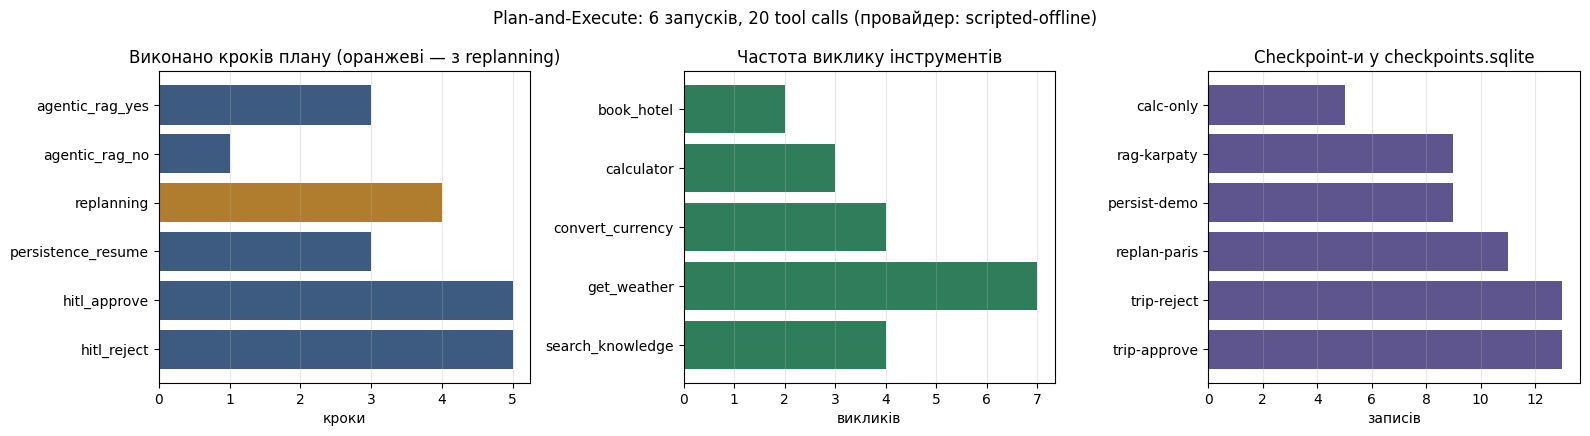

RAG використано у 4/6 запусків; replanning: 1; розподіл інструментів: {'search_knowledge': 4, 'get_weather': 7, 'convert_currency': 4, 'calculator': 3, 'book_hotel': 2}


In [15]:
import matplotlib.pyplot as plt

tags = [r["tag"] for r in RUN_LOG]
steps_done = [r["steps_done"] for r in RUN_LOG]
bar_colors = ["#3d5a80" if not r["replans"] else "#b07d2f" for r in RUN_LOG]
tool_usage = Counter(t for r in RUN_LOG for t in r["tools"])

with sqlite3.connect(CHECKPOINT_DB) as viz_conn:
    checkpoint_rows = viz_conn.execute(
        "SELECT thread_id, COUNT(*) FROM checkpoints GROUP BY thread_id ORDER BY 2 DESC").fetchall()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].barh(tags, steps_done, color=bar_colors)
axes[0].set_title("Виконано кроків плану (оранжеві — з replanning)")
axes[0].set_xlabel("кроки")
axes[0].invert_yaxis()

axes[1].barh(list(tool_usage), list(tool_usage.values()), color="#2f7d5b")
axes[1].set_title("Частота виклику інструментів")
axes[1].set_xlabel("викликів")

axes[2].barh([r[0] for r in checkpoint_rows], [r[1] for r in checkpoint_rows], color="#5e548e")
axes[2].set_title(f"Checkpoint-и у {CHECKPOINT_DB.name}")
axes[2].set_xlabel("записів")

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
fig.suptitle(f"Plan-and-Execute: {len(RUN_LOG)} запусків, "
             f"{sum(len(r['tools']) for r in RUN_LOG)} tool calls (провайдер: {ACTIVE_LLM._llm_type})")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plan_execute_results.png", dpi=120)
plt.show()

print(f"RAG використано у {sum(r['used_rag'] for r in RUN_LOG)}/{len(RUN_LOG)} запусків; "
      f"replanning: {sum(r['replans'] for r in RUN_LOG)}; розподіл інструментів: {dict(tool_usage)}")

# Закриваємо з'єднання checkpointer-ів: WAL-журнал зливається у checkpoints.sqlite.
main_conn.close()
restored_conn.close()

## Секція 11. Висновки та аналіз

### Що реалізовано
| Вимога | Реалізація |
|---|---|
| Plan-and-Execute граф | три вузли `planner → executor → replanner`, conditional edge `replanner → executor/END` |
| Structured outputs | `Plan` і `ReplanDecision` (Pydantic v2) через `with_structured_output` |
| Persistence | `SqliteSaver` поверх файлу `checkpoints.sqlite`; демо «збою» та відновлення за `thread_id` (Секція 8) |
| Agentic RAG | ChromaDB з 10 документів + інструмент `search_knowledge`; агент сам вирішує, коли йти в базу (Секція 6) |
| HITL | `interrupt()` перед `book_hotel` + `Command(resume=...)`; сценарії approve і reject (Секція 9) |
| Guardrails | `max_plan_steps`, `max_total_steps` проти нескінченного replanning |

### Спостереження: Plan-and-Execute vs ReAct
* **Прозорість.** План видно ДО виконання — його можна показати людині, залогувати й порівняти з фактичною
  траєкторією. У ReAct наступний крок стає відомий лише post factum.
* **Якість на довгих задачах.** Сценарій «поїздка до Львова» — 5 залежних кроків (знання → погода → валюта →
  бюджет → бронювання). Планувальник фіксує послідовність одразу, executor не «забуває» мету посередині.
* **Ціна.** Кожен крок — щонайменше 2 виклики LLM (executor + replanner) плюс планування, тобто помітно
  дорожче за ReAct на простих запитах. Для «порахуй 15%» ReAct ефективніший.
* **Replanning — головний запобіжник.** Без нього перший же `ERROR` інструмента зруйнував би весь план;
  з ним агент локально замінив крок і довів задачу до кінця (Секція 7).

### Роль production-можливостей
* **Persistence** перетворює агента на відновлюваний процес: «збій» коштує нуль втраченого прогресу,
  а `thread_id` стає ідентифікатором довгої сесії користувача.
* **Agentic RAG** прибирає галюцинації у доменних фактах: планувальник явно інструктується брати факти
  з бази, але сам вирішує, чи потрібен цей крок конкретному запиту.
* **HITL** ставить людину між рішенням агента та незворотною дією: interrupt зберігається у checkpointer,
  тому «чекати на approve» можна як завгодно довго — навіть після перезапуску процесу.

### Обмеження та можливі покращення
* Офлайн-фолбек скриптований: реальна варіативність планів з'являється лише з живим LLM-провайдером.
* `HashingEmbedding` — лексичний, без справжньої семантики; у production варто замінити на нейронні ембеддинги.
* Replanner викликається після КОЖНОГО кроку — для довгих планів варто перевіряти план лише після помилок
  або кожні N кроків.
* Approve/reject у ноутбуці подається програмно; у застосунку це буде UI поверх того самого
  `Command(resume=...)` API.